### Pytorch Dataset and DataLoader

In [1]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

DEVICE = (
    torch.device("mps")   if torch.backends.mps.is_available()
    else torch.device("cpu")
)
print(f"Using device: {DEVICE}")

CSV_PATH = Path("../data/cleaned_metadata.csv")
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows  |  train={len(df[df.split=='train']):,}  test={len(df[df.split=='test']):,}")

Using device: mps
Loaded 31,936 rows  |  train=25,548  test=6,388


In [2]:
IMG_SIZE = 260

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=20, scale=(0.85, 1.15), shear=10),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.08),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2)),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [3]:
class ClothingDataset(Dataset):
    """
    Returns front and back images as separate 3-channel tensors
    for the dual-stream architecture, plus a label dict.
    """

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        front = Image.open(row["front_path"]).convert("RGB")
        back  = Image.open(row["back_path"]).convert("RGB")

        if self.transform:
            front = self.transform(front)
            back  = self.transform(back)

        labels = {
            "condition": torch.tensor(row["condition"] - 1, dtype=torch.long),
            "stains":    torch.tensor(row["stains"],        dtype=torch.long),
            "holes":     torch.tensor(row["holes"],         dtype=torch.long),
            "fraud":     torch.tensor(float(row["is_fraud_candidate"]), dtype=torch.float),
        }
        return front, back, labels

In [4]:
BATCH_SIZE = 32

train_df = df[df["split"] == "train"]
test_df  = df[df["split"] == "test"]

train_dataset = ClothingDataset(train_df, transform=train_transforms)
test_dataset  = ClothingDataset(test_df,  transform=test_transforms)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

print(f"Train: {len(train_dataset):,} items → {len(train_loader):,} batches")
print(f"Test:  {len(test_dataset):,} items → {len(test_loader):,} batches")

Train: 25,548 items → 799 batches
Test:  6,388 items → 200 batches


In [5]:
# Sanity check: load one batch and inspect shapes + label ranges
fronts, backs, labels = next(iter(train_loader))
print(f"Front batch shape : {fronts.shape}")       # (B, 3, 260, 260)
print(f"Back batch shape  : {backs.shape}")        # (B, 3, 260, 260)
print(f"Condition range   : {labels['condition'].min().item()} – {labels['condition'].max().item()}")

Front batch shape : torch.Size([32, 3, 260, 260])
Back batch shape  : torch.Size([32, 3, 260, 260])
Condition range   : 0 – 4


### Model Architecture 

In [6]:
import timm

class ClothingConditionModel(nn.Module):
    """
    Dual-stream model for clothing condition grading (5-class).

    Architecture
    ------------
    A shared EfficientNet-B2 backbone processes the front and back
    images independently (weight-shared, standard 3-channel input).
    The two 1408-d feature vectors are concatenated into a 2816-d
    representation and fed through a single classification head.
    """

    def __init__(self, backbone_name: str = "efficientnet_b2", pretrained: bool = True):
        super().__init__()

        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            in_chans=3,
            num_classes=0,
            global_pool="avg",
        )

        feat_dim = self.backbone.num_features  # 1408

        self.head = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(feat_dim * 2, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 5),
        )

    def forward(self, front, back):
        f_front = self.backbone(front)   # (B, 1408)
        f_back  = self.backbone(back)    # (B, 1408)
        combined = torch.cat([f_front, f_back], dim=1)  # (B, 2816)
        return self.head(combined)       # (B, 5)

/opt/anaconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
model = ClothingConditionModel(pretrained=True).to(DEVICE)

# Phase 1: freeze backbone, only train the head
for param in model.backbone.parameters():
    param.requires_grad = False

total_params = sum(p.numel() for p in model.parameters())
trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params     : {total_params:,}")
print(f"Trainable params : {trainable:,}  (backbone frozen)")
print(f"Backbone features: {model.backbone.num_features}")

# Verify forward pass with one batch
with torch.no_grad():
    out = model(fronts.to(DEVICE), backs.to(DEVICE))
    print(f"  condition logits → {out.shape}")

Total params     : 8,423,431
Trainable params : 722,437  (backbone frozen)
Backbone features: 1408
  condition logits → torch.Size([32, 5])


### Training Loop

In [8]:
from tqdm import tqdm

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

MIXUP_ALPHA = 0.2

def mixup_data(x1, x2, y, alpha=MIXUP_ALPHA):
    """Apply mixup to a batch. Returns mixed inputs and (y_a, y_b, lam)."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    idx = torch.randperm(x1.size(0), device=x1.device)
    mixed_x1 = lam * x1 + (1 - lam) * x1[idx]
    mixed_x2 = lam * x2 + (1 - lam) * x2[idx]
    return mixed_x1, mixed_x2, y, y[idx], lam

def mixup_criterion(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)

USE_AMP = DEVICE.type in ("cuda", "mps")
amp_dtype = torch.float16 if DEVICE.type == "cuda" else torch.float16
print(f"Mixed precision: {USE_AMP}  dtype: {amp_dtype}")

Mixed precision: True  dtype: torch.float16


In [9]:
HEAD_LR       = 1e-3
BACKBONE_LR   = 1e-4
NUM_EPOCHS    = 15
UNFREEZE_AT   = 2
PATIENCE      = 3
SAVE_DIR      = Path("../checkpoints")
SAVE_DIR.mkdir(exist_ok=True)

head_params = [p for n, p in model.named_parameters() if "backbone" not in n]
optimizer = torch.optim.AdamW(head_params, lr=HEAD_LR, weight_decay=1e-4)

# OneCycleLR: warmup then aggressive decay, stepped per batch
steps_per_epoch = len(train_loader)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=HEAD_LR,
    epochs=NUM_EPOCHS,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy="cos",
)

def unfreeze_backbone(model, optimizer, remaining_epochs, steps_per_epoch):
    """Unfreeze backbone and add its params with a lower LR. Rebuild scheduler."""
    for param in model.backbone.parameters():
        param.requires_grad = True
    optimizer.add_param_group({
        "params": list(model.backbone.parameters()),
        "lr": BACKBONE_LR,
        "weight_decay": 1e-4,
    })
    new_scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=[HEAD_LR * 0.5, BACKBONE_LR],
        epochs=remaining_epochs,
        steps_per_epoch=steps_per_epoch,
        pct_start=0.05,
        anneal_strategy="cos",
    )
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  ★ Backbone unfrozen — trainable params: {trainable:,}")
    return new_scheduler

In [10]:
step_log = {"step": [], "loss": [], "acc": []}

def train_one_epoch(model, loader, optimizer, scheduler, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    window_loss = 0.0
    window_correct = 0
    window_total = 0

    num_batches = len(loader)
    log_every = max(1, num_batches // 20)
    global_offset = (epoch - 1) * num_batches

    pbar = tqdm(loader, desc="  train", leave=False)
    for batch_idx, (fronts, backs, labels) in enumerate(pbar):
        fronts  = fronts.to(DEVICE)
        backs   = backs.to(DEVICE)
        targets = labels["condition"].to(DEVICE)

        fronts, backs, y_a, y_b, lam = mixup_data(fronts, backs, targets)

        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
            logits = model(fronts, backs)
            loss = mixup_criterion(criterion, logits, y_a, y_b, lam)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        bs = fronts.size(0)
        running_loss += loss.item() * bs
        correct += (logits.argmax(1) == targets).sum().item()
        total += bs

        window_loss += loss.item() * bs
        window_correct += (logits.argmax(1) == targets).sum().item()
        window_total += bs

        if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == num_batches:
            step_log["step"].append(global_offset + batch_idx + 1)
            step_log["loss"].append(window_loss / window_total)
            step_log["acc"].append(window_correct / window_total)
            window_loss = 0.0
            window_correct = 0
            window_total = 0

        if DEVICE.type == "mps":
            torch.mps.synchronize()

        pbar.set_postfix(loss=f"{loss.item():.3f}")

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_targets = []

    for fronts, backs, labels in tqdm(loader, desc="  eval ", leave=False):
        fronts  = fronts.to(DEVICE)
        backs   = backs.to(DEVICE)
        targets = labels["condition"].to(DEVICE)

        with torch.autocast(device_type=DEVICE.type, dtype=amp_dtype, enabled=USE_AMP):
            logits = model(fronts, backs)
            loss = criterion(logits, targets)

        preds = logits.argmax(1)
        running_loss += loss.item() * fronts.size(0)
        correct += (preds == targets).sum().item()
        total += fronts.size(0)

        all_preds.append(preds.cpu())
        all_targets.append(targets.cpu())

    all_preds = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)
    return running_loss / total, correct / total, all_preds, all_targets

In [11]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

best_val_loss = float("inf")
patience_counter = 0
last_preds = None
last_targets = None

for epoch in range(1, NUM_EPOCHS + 1):
    if epoch == UNFREEZE_AT:
        remaining = NUM_EPOCHS - epoch + 1
        scheduler = unfreeze_backbone(model, optimizer, remaining, steps_per_epoch)

    lrs = " / ".join(f"{g['lr']:.2e}" for g in optimizer.param_groups)
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  (lr={lrs})")

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, scheduler, epoch)
    val_loss, val_acc, last_preds, last_targets = evaluate(model, test_loader)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  train  loss={train_loss:.4f}  acc={train_acc:.4f}")
    print(f"  val    loss={val_loss:.4f}  acc={val_acc:.4f}")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_val_loss": best_val_loss,
        "history": history,
        "step_log": step_log,
    }
    torch.save(checkpoint, SAVE_DIR / "last_checkpoint.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(checkpoint, SAVE_DIR / "best_checkpoint.pt")
        print(f"  ✓ saved best checkpoint (val_loss={val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  ✗ no improvement ({patience_counter}/{PATIENCE})")
        if patience_counter >= PATIENCE:
            print(f"\n  Early stopping at epoch {epoch}")
            break

print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")


Epoch 1/15  (lr=4.00e-05)


  train  loss=1.4831  acc=0.3140
  val    loss=1.4417  acc=0.3763
  ✓ saved best checkpoint (val_loss=1.4417)
  ★ Backbone unfrozen — trainable params: 8,423,431

Epoch 2/15  (lr=2.00e-05 / 4.00e-06)


  train  loss=1.4479  acc=0.3349
  val    loss=1.3930  acc=0.4158
  ✓ saved best checkpoint (val_loss=1.3930)

Epoch 3/15  (lr=4.99e-04 / 9.99e-05)


  train  loss=1.4115  acc=0.3509
  val    loss=1.3785  acc=0.4139
  ✓ saved best checkpoint (val_loss=1.3785)

Epoch 4/15  (lr=4.88e-04 / 9.77e-05)


  train  loss=1.3899  acc=0.3542
  val    loss=1.3593  acc=0.4385
  ✓ saved best checkpoint (val_loss=1.3593)

Epoch 5/15  (lr=4.64e-04 / 9.28e-05)


...

  train  loss=1.3578  acc=0.3691
  val    loss=1.3433  acc=0.4460
  ✓ saved best checkpoint (val_loss=1.3433)

Epoch 7/15  (lr=3.82e-04 / 7.63e-05)


  train  loss=1.3450  acc=0.3740
  val    loss=1.3417  acc=0.4485
  ✓ saved best checkpoint (val_loss=1.3417)

Epoch 8/15  (lr=3.28e-04 / 6.57e-05)


  train  loss=1.3235  acc=0.3811
  val    loss=1.3425  acc=0.4601
  ✗ no improvement (1/3)

Epoch 9/15  (lr=2.71e-04 / 5.41e-05)


  train  loss=1.3003  acc=0.3969
  val    loss=1.3500  acc=0.4530
  ✗ no improvement (2/3)

Epoch 10/15  (lr=2.12e-04 / 4.23e-05)


  train  loss=1.2724  acc=0.3965
  val    loss=1.3691  acc=0.4523
  ✗ no improvement (3/3)

  Early stopping at epoch 10

Training complete. Best val loss: 1.3417


Time to run: 

In [12]:
import json as _json

# Save JSON copies of history for easy inspection outside of PyTorch
history_path  = SAVE_DIR / "training_history.json"
step_log_path = SAVE_DIR / "step_log.json"

with open(history_path, "w") as f:
    _json.dump(history, f, indent=2)
with open(step_log_path, "w") as f:
    _json.dump(step_log, f, indent=2)

print(f"Saved history  → {history_path}")
print(f"Saved step_log → {step_log_path}")
print(f"Full checkpoints in {SAVE_DIR}: best_checkpoint.pt, last_checkpoint.pt")

Saved history  → ../checkpoints/training_history.json
Saved step_log → ../checkpoints/step_log.json
Full checkpoints in ../checkpoints: best_checkpoint.pt, last_checkpoint.pt


In [13]:
import json as _json
from pathlib import Path as _Path

_save = _Path("../checkpoints")
try:
    _needs_reload = not history.get("train_loss")
except NameError:
    _needs_reload = True

if _needs_reload:
    _ckpt_path = _save / "last_checkpoint.pt"
    if _ckpt_path.exists():
        _ckpt = torch.load(_ckpt_path, map_location="cpu", weights_only=False)
        history  = _ckpt["history"]
        step_log = _ckpt["step_log"]
        print(f"Reloaded from checkpoint (epoch {_ckpt['epoch']})")
    else:
        with open(_save / "training_history.json") as f:
            history = _json.load(f)
        with open(_save / "step_log.json") as f:
            step_log = _json.load(f)
        print("Reloaded history & step_log from JSON")
else:
    print("Using in-memory history (no reload needed)")

Using in-memory history (no reload needed)


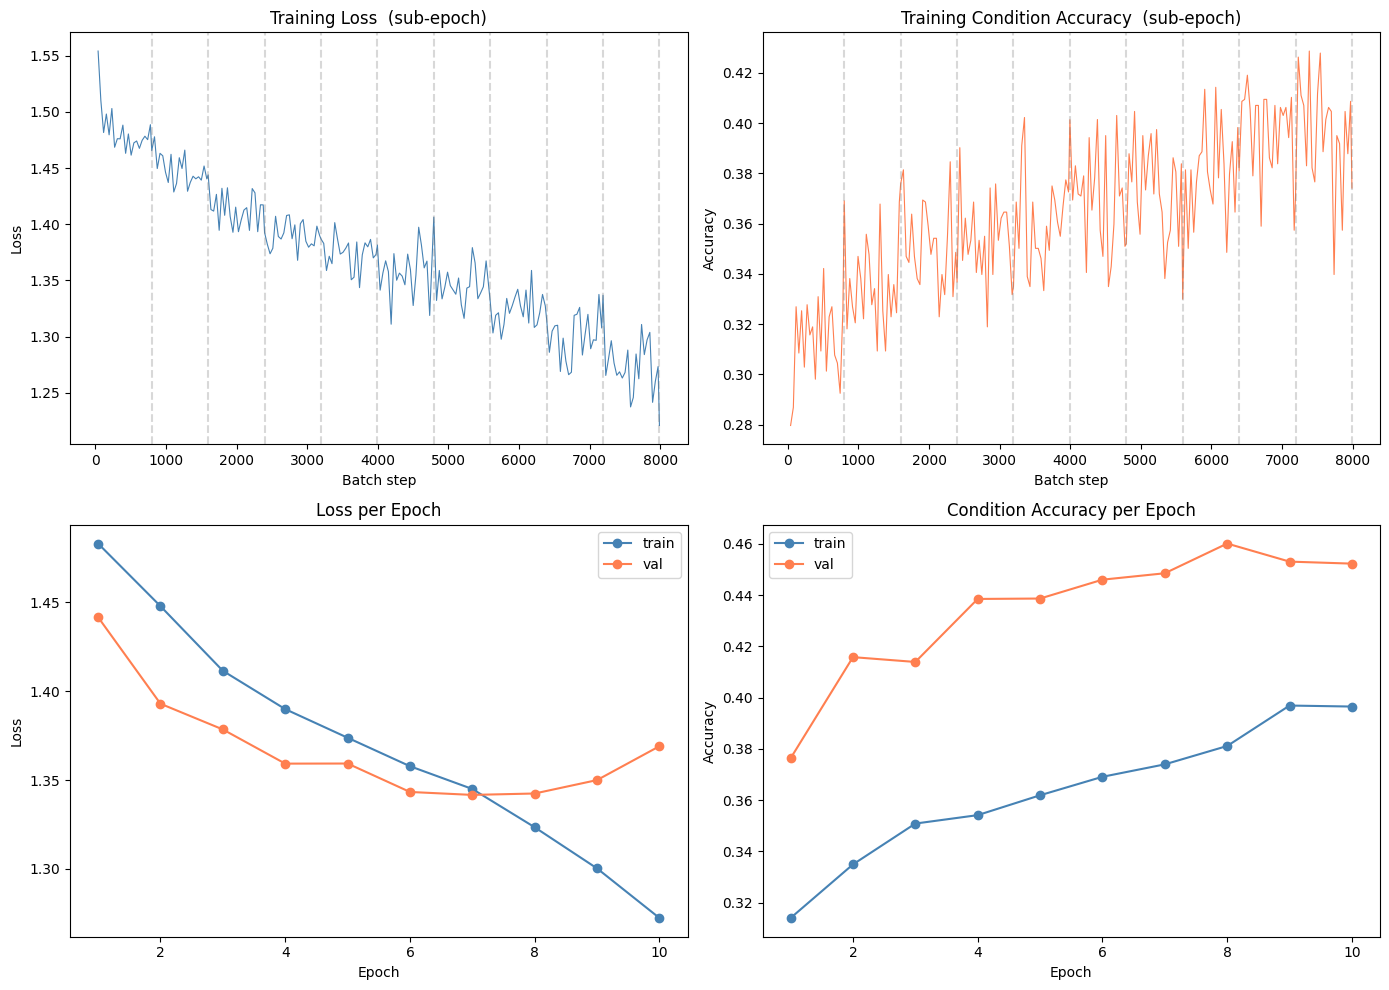

In [14]:
import matplotlib.pyplot as plt

n_actual = len(history["train_loss"])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Sub-epoch training curves
axes[0, 0].plot(step_log["step"], step_log["loss"], linewidth=0.8, color="steelblue")
axes[0, 0].set_title("Training Loss  (sub-epoch)")
axes[0, 0].set_xlabel("Batch step")
axes[0, 0].set_ylabel("Loss")
for e in range(1, n_actual + 1):
    axes[0, 0].axvline(x=e * len(train_loader), color="grey", linestyle="--", alpha=0.3)

axes[0, 1].plot(step_log["step"], step_log["acc"], linewidth=0.8, color="coral")
axes[0, 1].set_title("Training Condition Accuracy  (sub-epoch)")
axes[0, 1].set_xlabel("Batch step")
axes[0, 1].set_ylabel("Accuracy")
for e in range(1, n_actual + 1):
    axes[0, 1].axvline(x=e * len(train_loader), color="grey", linestyle="--", alpha=0.3)

# Per-epoch train vs val
epochs = range(1, n_actual + 1)

axes[1, 0].plot(epochs, history["train_loss"], "o-", label="train", color="steelblue")
axes[1, 0].plot(epochs, history["val_loss"],   "o-", label="val",   color="coral")
axes[1, 0].set_title("Loss per Epoch")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()

axes[1, 1].plot(epochs, history["train_acc"], "o-", label="train", color="steelblue")
axes[1, 1].plot(epochs, history["val_acc"],   "o-", label="val",   color="coral")
axes[1, 1].set_title("Condition Accuracy per Epoch")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylabel("Accuracy")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

### Evaluation and Reporting

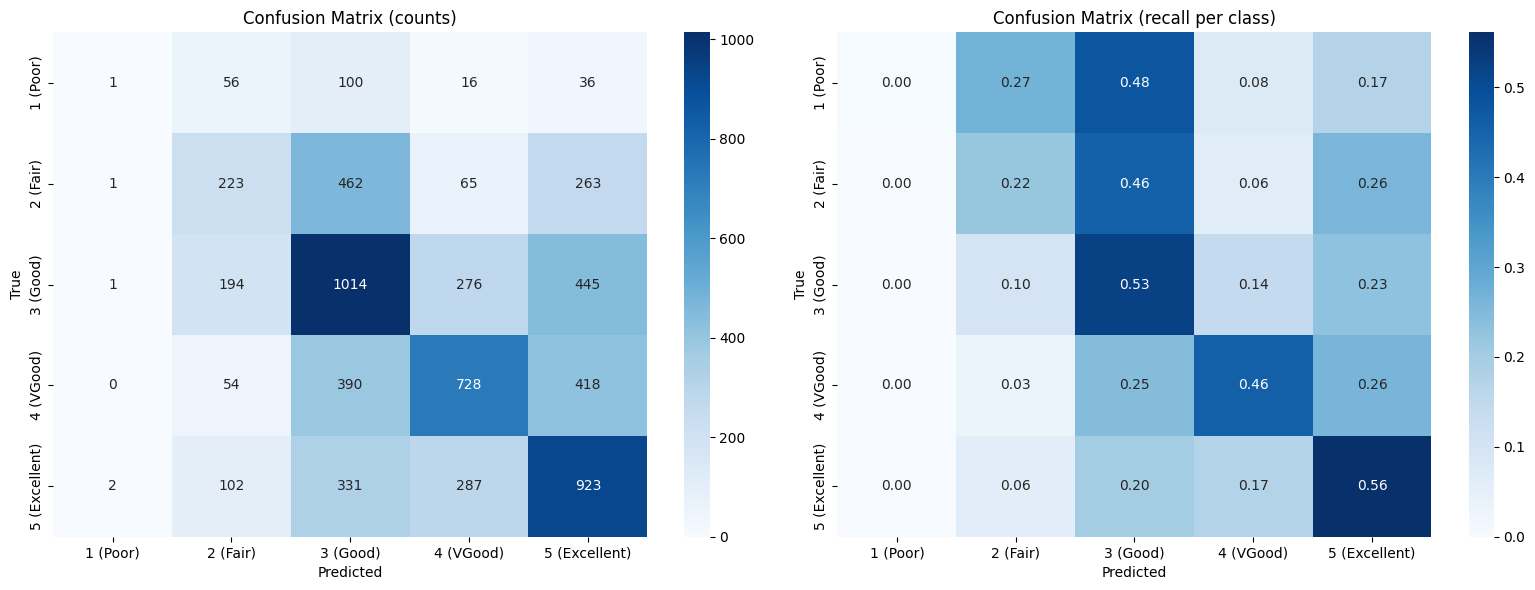


               precision    recall  f1-score   support

     1 (Poor)       0.20      0.00      0.01       209
     2 (Fair)       0.35      0.22      0.27      1014
     3 (Good)       0.44      0.53      0.48      1930
    4 (VGood)       0.53      0.46      0.49      1590
5 (Excellent)       0.44      0.56      0.49      1645

     accuracy                           0.45      6388
    macro avg       0.39      0.35      0.35      6388
 weighted avg       0.44      0.45      0.44      6388



In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Use last_preds/last_targets from training loop, or re-evaluate from best checkpoint
try:
    preds_np = last_preds.numpy()
    targets_np = last_targets.numpy()
except NameError:
    print("Re-evaluating from best checkpoint...")
    _ckpt = torch.load(SAVE_DIR / "best_checkpoint.pt", map_location=DEVICE, weights_only=False)
    model.load_state_dict(_ckpt["model_state_dict"])
    _, _, last_preds, last_targets = evaluate(model, test_loader)
    preds_np = last_preds.numpy()
    targets_np = last_targets.numpy()

cond_labels = ["1 (Poor)", "2 (Fair)", "3 (Good)", "4 (VGood)", "5 (Excellent)"]

cm = confusion_matrix(targets_np, preds_np)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=cond_labels, yticklabels=cond_labels, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (counts)")

# Row-normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=cond_labels, yticklabels=cond_labels, ax=axes[1])
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (recall per class)")

plt.tight_layout()
plt.show()

print("\n" + classification_report(targets_np, preds_np, target_names=cond_labels))